In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from pathlib import Path

from dusty_colors.utils import load_stack

In [26]:
# Digitization of previous results
menard = np.array(
    [
        0.015372588004246894,
        0.16363373083250488,
        0.027147818672390675,
        0.08523850777558134,
        0.04794274447902959,
        0.03541057247645705,
        0.08584894051000302,
        0.03183392387526768,
        0.15372588004246884,
        0.013401938789527565,
        0.2714781867239069,
        0.008753798222678313,
        0.48612391624802315,
        0.007074748123832496,
        0.8584894051000298,
        0.004499654732304847,
        1.537258800424686,
        0.0033130745918951094,
        2.7147818672390636,
        0.0022823461023140207,
        4.861239162480231,
        0.0009867784425089342,
        0.015372588004246894,
        0.19454377598866124,
        0.027147818672390675,
        0.10269769440034786,
        0.04794274447902959,
        0.04440162288571723,
        0.08584894051000302,
        0.03734688077726687,
        0.15372588004246884,
        0.017029969604826688,
        0.2714781867239069,
        0.011123533691669145,
        0.48612391624802315,
        0.008638059376211973,
        0.8584894051000298,
        0.005794364085237468,
        1.537258800424686,
        0.00420995502849078,
        2.7147818672390636,
        0.0030183443573722673,
        4.794274447902952,
        0.0015514988038209934,
    ]
)
menard = menard.reshape(22, 2)

menard_x = menard[:11, 0]
menard_y = menard[:11, 1]

menard_err = menard[11:, 1] - menard_y

# TODO: Add upper limits
kids = np.array(
    [
        0.2952434728405713,
        0.011686711085103491,
        1.3939400795413572,
        0.002833398713044844,
        3.028837722476841,
        0.0017255322353215614,
        6.581242683055025,
        0.0009789696561929445,
        14.300124081209015,
        0.000716777914648752,
        0.2952434728405713,
        0.021191116846058046,
        1.3939400795413572,
        0.004458931178088874,
        3.028837722476841,
        0.0029148444562188815,
        6.581242683055025,
        0.0018261584682702627,
        14.300124081209015,
        0.0012456172541058495,
    ]
)
kids = kids.reshape(10, 2)

kids_x = kids[:5, 0]
kids_y = kids[:5, 1]

kids_err = kids[5:, 1] - kids_y

# Convert arcmin -> Mpc
arcmin_per_Mpc = 1e3 / (5.078 * 60)
kids_x /= arcmin_per_Mpc

# Convert Av -> reddening
Rv = 3.1
kids_y *= Rv
kids_err *= Rv

In [27]:
r_norm = 3.5

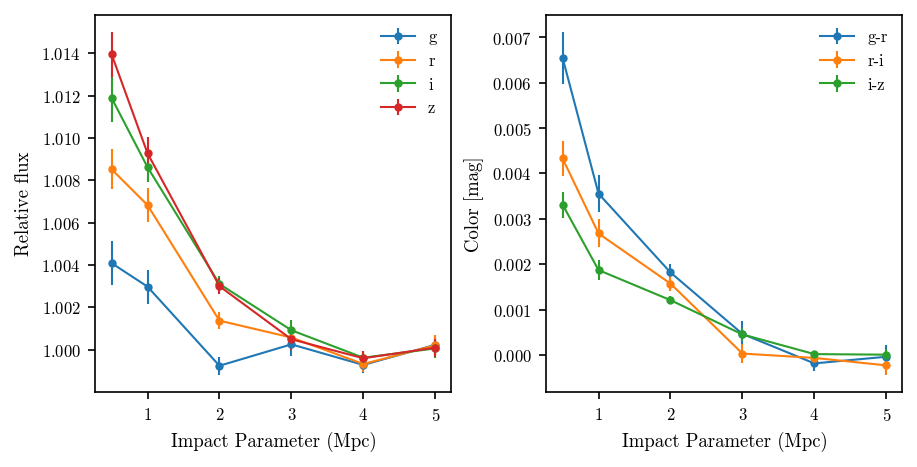

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3), constrained_layout=True, dpi=150)

data = load_stack(
    Path("../results_main/stacks/default"),
    stack_type="fluxes",
    r_norm=r_norm,
)

for band in "griz":
    N = -1
    x = data[f"{band}_bin_centers"]
    y = -2.5 * np.log10(data[f"{band}_avg"])
    yerr = 2.5 / np.log(10) * data[f"{band}_err"] / data[f"{band}_avg"]
    y = data[f"{band}_avg"]
    yerr = data[f"{band}_err"]
    ax1.errorbar(
        x[:N],
        y[:N],
        yerr=yerr[:N],
        marker=".",
        label=band,
    )
ax1.legend(frameon=False, fontsize=8)
ax1.set(xlabel="Impact Parameter (Mpc)", ylabel="Relative flux")


data = load_stack(
    Path("../results_main/stacks/default"),
    stack_type="fcolors",
    r_norm=r_norm,
)

for color in ["g-r", "r-i", "i-z"]:
    N = -1
    x = data[f"{color}_bin_centers"]
    y = -2.5 * np.log10(data[f"{color}_avg"])
    yerr = 2.5 / np.log(10) * data[f"{color}_err"] / data[f"{color}_avg"]
    ax2.errorbar(
        x[:N],
        y[:N],
        yerr=yerr[:N],
        marker=".",
        label=color,
    )
ax2.legend(frameon=False, fontsize=8)
ax2.set(xlabel="Impact Parameter (Mpc)", ylabel="Color [mag]")

fig.savefig("../figures/flux_and_color_profiles.pdf", bbox_inches="tight")

Best fit power law:
    scale = 5.1e-03 ± 6.1e-04
    index = -0.90 ± 0.19


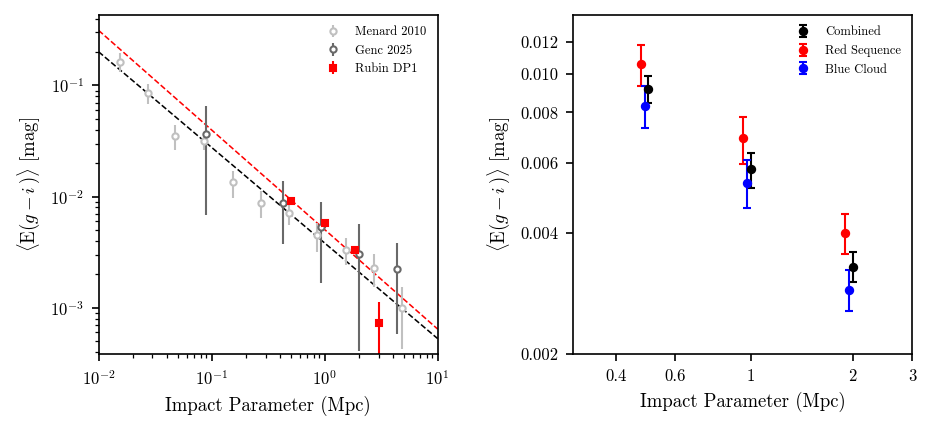

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), dpi=150)

x = np.logspace(-2, 1, 100)
y = x**-0.86 * np.mean(menard_y / (menard_x**-0.86))
ax1.plot(x, y, c="k", ls="--", lw=0.75, zorder=-1)  # , label="Menard power law")

ax1.set(
    xscale="log",
    yscale="log",
    xlabel="Impact Parameter (Mpc)",
    ylabel="$\\langle \\mathrm{E}(g-i\\,) \\rangle$ [mag]",
    xlim=(x.min(), x.max()),
)
ax1.set_box_aspect(1)

ax1.errorbar(
    menard_x,
    menard_y,
    yerr=menard_err,
    c="silver",
    mfc="w",
    ls="",
    marker=".",
    label="Menard 2010",
)

ax1.errorbar(
    kids_x,
    kids_y,
    yerr=kids_err,
    c="dimgray",
    mfc="w",
    ls="",
    marker=".",
    label="Genc 2025",
)

data = load_stack(
    Path("../results_main/stacks/default"),
    stack_type="fcolors",
    r_norm=r_norm,
)

N = 4
x = data["g-i_bin_centers"].copy()
y = -2.5 * np.log10(data["g-i_avg"])
yerr = 2.5 / np.log(10) * data["g-i_err"] / data["g-i_avg"]

x[2] -= 0.15

ax1.errorbar(
    x[:N],
    y[:N],
    yerr=yerr[:N],
    color="r",
    label="Rubin DP1",
    ls="",
    marker="s",
    markersize=3,
)

ax1.legend(loc="upper right", fontsize=6, frameon=False)


def power_law(x, A, alpha):
    return A * x**alpha


popt, pcov = curve_fit(power_law, x[:N], y[:N], p0=[0.006, -0.86])
print("Best fit power law:")
print(f"    scale = {popt[0]:.1e} ± {np.sqrt(pcov[0, 0]):.1e}")
print(f"    index = {popt[1]:.2f} ± {np.sqrt(pcov[1, 1]):.2f}")
x = np.logspace(-2, 1, 100)
ax1.plot(x, power_law(x, *popt), c="r", ls="--", lw=0.75, zorder=-1)


def plot_stack(name, label, color, x_scale=1.0):

    data = load_stack(
        Path(f"../results_main/stacks/{name}"),
        stack_type="fcolors",
        r_norm=r_norm,
    )

    N = 4
    x = data["g-i_bin_centers"].copy() * x_scale
    y = -2.5 * np.log10(data["g-i_avg"])
    yerr = 2.5 / np.log(10) * data["g-i_err"] / data["g-i_avg"]

    ax2.errorbar(
        x[:N],
        y[:N],
        yerr=yerr[:N],
        color=color,
        label=label,
        ls="",
        marker=".",
        markersize=7,
        capsize=2,
    )


plot_stack("default", "Combined", "k", x_scale=1.0)
plot_stack("fg_red_sequence", "Red Sequence", "r", x_scale=0.95)
plot_stack("fg_blue_cloud", "Blue Cloud", "b", x_scale=0.975)


ax2.legend(loc="upper right", fontsize=6, frameon=False)

xticks = [0.4, 0.6, 1, 2, 3]
yticks = [2e-3, 4e-3, 6e-3, 8e-3, 10e-3, 12e-3]
ax2.set(
    xscale="log",
    yscale="log",
    xlabel="Impact Parameter (Mpc)",
    ylabel="$\\langle \\mathrm{E}(g-i\\,) \\rangle$ [mag]",
    xlim=(0.3, 3),
    ylim=(2e-3, 1.4e-2),
    xticks=xticks,
    xticklabels=[str(tick) for tick in xticks],
    yticks=yticks,
    yticklabels=[f"{tick:.3f}" for tick in yticks],
)
ax2.set_box_aspect(1)
plt.minorticks_off()

fig.subplots_adjust(wspace=0.4)


fig.savefig("../figures/main_result.pdf", bbox_inches="tight")

In [241]:
from dust_extinction.parameter_averages import O94
from astropy import units as u
from scipy.optimize import minimize

In [281]:
# Define color dependence
def f(wavelen, Rv):
    ext = O94(Rv=Rv)
    return ext(wavelen)


def A(wavelen, r, C, alpha, Rv):
    return C * r**alpha * f(wavelen, Rv)


wavelen_g = 0.478 * u.micron
wavelen_r = 0.619 * u.micron
wavelen_i = 0.754 * u.micron
wavelen_z = 0.867 * u.micron


def model(params):
    Egr = A(
        wavelen_g,
        data["g-r_bin_centers"][:N],
        *params,
    ) - A(
        wavelen_r,
        data["g-r_bin_centers"][:N],
        *params,
    )
    Eri = A(
        wavelen_r,
        data["g-r_bin_centers"][:N],
        *params,
    ) - A(
        wavelen_i,
        data["g-r_bin_centers"][:N],
        *params,
    )
    Eiz = A(
        wavelen_i,
        data["g-r_bin_centers"][:N],
        *params,
    ) - A(
        wavelen_z,
        data["g-r_bin_centers"][:N],
        *params,
    )

    Egr_obs = -2.5 * np.log10(data["g-r_avg"][:N])
    Egr_err = 2.5 / np.log(10) * data["g-r_err"][:N] / data["g-r_avg"][:N]

    Eri_obs = -2.5 * np.log10(data["r-i_avg"][:N])
    Eri_err = 2.5 / np.log(10) * data["r-i_err"][:N] / data["r-i_avg"][:N]

    Eiz_obs = -2.5 * np.log10(data["i-z_avg"][:N])
    Eiz_err = 2.5 / np.log(10) * data["i-z_err"][:N] / data["i-z_avg"][:N]

    return np.array(
        [[Egr, Egr_obs, Egr_err], [Eri, Eri_obs, Eri_err], [Eiz, Eiz_obs, Eiz_err]]
    )


def chi_squared(params):
    model_vals = model(params)
    chi2 = np.sum(np.square((model_vals[:, 0] - model_vals[:, 1]) / model_vals[:, 2]))
    return chi2


out = minimize(chi_squared, [4.4e-3, -0.86, 3.1])
print(f"C = {out.x[0]:.1e}")
print(f"alpha = {out.x[1]:.2f}")
print(f"Rv = {out.x[2]:.1f}")
out

C = 1.4e-02
alpha = -0.93
Rv = 4.7


  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 37.751907604104595
        x: [ 1.366e-02 -9.294e-01  4.655e+00]
      nit: 13
      jac: [-5.198e-05  2.384e-06  4.768e-07]
 hess_inv: [[ 1.037e-07 -1.685e-06  2.164e-06]
            [-1.685e-06  1.199e-03 -1.792e-03]
            [ 2.164e-06 -1.792e-03  2.680e-03]]
     nfev: 152
     njev: 38

$$

A(\lambda) = 1.4 \times 10^{-2} \left(\frac{r}{1\,\mathrm{Mpc}}\right)^{-0.93} f(\lambda; R_V = 4.7)

$$

where $f$ is the O'Donnell (1994) dust extinction law.

Cf. Menard:
$$

\mathrm{norm} = (8.5 \pm 2.1) \times 10^{-4} \\
\mathrm{index} = -0.86 \pm 0.19 \\
R_V = 4.9 \pm 3.2

$$